# Chest X-Ray Pneumonia (Transfer Learning Experiment )
- ### EDA & Preprocessing

##  Environment

In [ ]:
from pathlib import Path

# DATA_DIR = Path("/content/chest_xray_processed")
DATA_DIR = Path("/content/chest_xray")

print("DATA_DIR 존재:", DATA_DIR.exists())

if DATA_DIR.exists():
    print("Train:", (DATA_DIR / "train").exists())
    print("Val  :", (DATA_DIR / "val").exists())
    print("Test :", (DATA_DIR / "test").exists())

DATA_DIR 존재: True
Train: True
Val  : True
Test : True


In [2]:
# AI Development Env. Check 

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import plotly

# import scipy
# import torchvision
# import PIL
# import tqdm
# import pynvml

print(f"Python: {__import__('sys').version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Plotly: {plotly.__version__}")
# print(f"PyTorch: {torch.__version__}")

# print(f"Pillow: {PIL.__version__}")
# print(f"tqdm: {tqdm.__version__}")
# print(f"TorchVision: {torchvision.__version__}")
# print(f"SciPy: {scipy.__version__}")


Python: 3.14.7
NumPy: 2.5.3
Pandas: 3.0.5
scikit-learn: 1.9.1
Matplotlib: 3.11.2
Seaborn: 0.13.2
Plotly: 7.1.0


In [3]:

from ailib.device import get_device, inspect_device 

inspect_device()

device = get_device() 


=== PyTorch Environment ===
PyTorch        : 2.14.0+cu126
Device         : cuda
CUDA Available : True
GPU            : NVIDIA GeForce GTX 1650


## 1. 데이터 확인  
- File Count: 5,856건
- Data Split
  - Train: NORMAL 1,341 / PNEUMONIA 3,875
  - Validation: NORMAL 8 / PNEUMONIA 8
  - Test: NORMAL 234 / PNEUMONIA 390
- File Size: 5.31 KB ~ 2,257 KB
- Missing File: 없음
- Image Size: 이미지별 원본 해상도가 다양함
- Class Distribution: Train에서 PNEUMONIA 이미지가 NORMAL보다 많음

In [4]:
#Custom Util
from ailib.image import ImageInspector 
# from ailib.image import ImagePreprocessor

# 기본설정
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
#PC
SRC_FOLDER = "data/chest-xray-pneumonia/chest_xray"

# Image 구성, 구조
inspector = ImageInspector()

inspector.overview_dataset(SRC_FOLDER)

{'Root': 'data\\chest-xray-pneumonia\\chest_xray',
 'Total Files': 5856,
 'Image Files': 5856,
 'Other Files': 0,
 'Total Size (MB)': 1179.2,
 'Image Size (MB)': 1179.2,
 'Avg Image Size (KB)': np.float64(206.2),
 'Min Image Size (KB)': np.float64(5.31),
 'Max Image Size (KB)': np.float64(2357.76)}

In [ ]:
# Folder별
inspector.overview_folders(SRC_FOLDER)

,Folder,Image Count,Total Size (MB),Average Size (KB),.jpeg
0,val\NORMAL,8,2.29,293.58,8
1,val\PNEUMONIA,8,0.60,76.35,8
2,train\NORMAL,1341,782.16,597.27,1341
3,train\PNEUMONIA,3875,318.76,84.23,3875
4,test\NORMAL,234,47.49,207.81,234
5,test\PNEUMONIA,390,27.91,73.27,390


In [ ]:
# format별
inspector.overview_formats(SRC_FOLDER)

,Format,Count
0,.jpeg,5856


In [ ]:
# 실제 이미지 구조

image_info_sample  = inspector.inspect_dataset(SRC_FOLDER, sample_size=10 )
image_info_sample 

# structure_info[
#     structure_info["Folder"].str.startswith("test")
# ].head()

,Folder,File,Format,Width,Height,Shape,Channels,Mode,DType,File Size (KB),Missing,Min,Max,Mean,Std,Error
0,val\NORMAL,NORMAL2-IM-1427-0001.jpeg,JPEG,1776,1416,"(1416, 1776)",1,L,uint8,247.20,0,0.0,255.0,143.627463,69.142481,None
1,val\NORMAL,NORMAL2-IM-1430-0001.jpeg,JPEG,1272,1040,"(1040, 1272)",1,L,uint8,256.56,0,0.0,255.0,140.128916,66.024124,None
2,val\NORMAL,NORMAL2-IM-1431-0001.jpeg,JPEG,1736,1416,"(1416, 1736)",1,L,uint8,244.52,0,0.0,255.0,151.964593,68.627445,None
3,val\NORMAL,NORMAL2-IM-1436-0001.jpeg,JPEG,1288,928,"(928, 1288)",1,L,uint8,242.99,0,0.0,255.0,102.582411,66.182869,None
4,val\NORMAL,NORMAL2-IM-1437-0001.jpeg,JPEG,1240,1104,"(1104, 1240)",1,L,uint8,208.73,0,0.0,255.0,130.460525,64.558986,None
5,val\NORMAL,NORMAL2-IM-1438-0001.jpeg,JPEG,1328,1104,"(1104, 1328)",1,L,uint8,166.88,0,0.0,255.0,139.756414,69.184624,None
6,val\NORMAL,NORMAL2-IM-1440-0001.jpeg,JPEG,1632,1225,"(1225, 1632)",1,L,uint8,517.72,0,0.0,255.0,93.048922,59.230327,None
7,val\NORMAL,NORMAL2-IM-1442-0001.jpeg,JPEG,1564,1302,"(1302, 1564)",1,L,uint8,464.01,0,0.0,255.0,88.607720,54.015039,None
8,val\PNEUMONIA,person1946_bacteria_4874.jpeg,JPEG,968,592,"(592, 968)",1,L,uint8,59.69,0,0.0,255.0,114.569049,54.684878,None
9,val\PNEUMONIA,person1946_bacteria_4875.jpeg,JPEG,1072,712,"(712, 1072)",1,L,uint8,57.87,0,0.0,255.0,98.546891,55.090193,None


In [ ]:
# File Valid Check
inspector.find_invalid_files(SRC_FOLDER) 

[]

In [ ]:
#  이미지 구조 그룹화 
inspector.group_image_structure(image_info_sample)

,Folder,Width,Height,Shape,Channels,Mode,DType,Count
0,val\NORMAL,1240,1104,"(1104, 1240)",1,L,uint8,1
1,val\NORMAL,1272,1040,"(1040, 1272)",1,L,uint8,1
2,val\NORMAL,1288,928,"(928, 1288)",1,L,uint8,1
3,val\NORMAL,1328,1104,"(1104, 1328)",1,L,uint8,1
4,val\NORMAL,1564,1302,"(1302, 1564)",1,L,uint8,1
5,val\NORMAL,1632,1225,"(1225, 1632)",1,L,uint8,1
6,val\NORMAL,1736,1416,"(1416, 1736)",1,L,uint8,1
7,val\NORMAL,1776,1416,"(1416, 1776)",1,L,uint8,1
8,val\PNEUMONIA,968,592,"(592, 968)",1,L,uint8,1
9,val\PNEUMONIA,1072,712,"(712, 1072)",1,L,uint8,1


## 2. 이미지 시각적 확인 

#### 대표이미지

In [ ]:
from pathlib import Path
from PIL import Image 

from ailib.image import ImageAnalyzer
from ailib.image_viewer import ImageViewer 
# ============================================================
# Dataset Path
# ============================================================

train_path = Path(SRC_FOLDER) / "train"
val_path = Path(SRC_FOLDER) / "val"
test_path = Path(SRC_FOLDER) / "test"



normal_files = list((train_path / "NORMAL").glob("*"))
pneumonia_files = list((train_path / "PNEUMONIA").glob("*"))

print("NORMAL:", len(normal_files))
print("PNEUMONIA:", len(pneumonia_files))

NORMAL: 1341
PNEUMONIA: 3875


In [ ]:
# 전체 이미지 정보 (이미지가 많아 1회 수행후 csv에 저장 -> 추가 분석할때는 csv 불러서 )
# *** Train 만 진행해야함 ****
image_info = inspector.inspect_dataset(train_path)
image_info.head()

In [24]:

image_info.to_csv(
    "image_info_chest-xray.csv",
    index=False
)

In [8]:
import pandas as pd

image_info2 = pd.read_csv(
    "image_info_chest-xray.csv"
)

image_info2.head()

,Folder,File,Format,Width,Height,Shape,Channels,Mode,DType,File Size (KB),Missing,Min,Max,Mean,Std,Error,Ratio,Area
0,NORMAL,IM-0115-0001.jpeg,JPEG,2090,1858,"(1858, 2090)",1,L,uint8,850.38,0,0.0,255.0,128.907478,62.301030,NaN,1.124865,3883220
1,NORMAL,IM-0117-0001.jpeg,JPEG,1422,1152,"(1152, 1422)",1,L,uint8,396.78,0,0.0,255.0,100.650624,59.808347,NaN,1.234375,1638144
2,NORMAL,IM-0119-0001.jpeg,JPEG,1810,1434,"(1434, 1810)",1,L,uint8,568.98,0,0.0,255.0,121.971530,68.856428,NaN,1.262204,2595540
3,NORMAL,IM-0122-0001.jpeg,JPEG,1618,1279,"(1279, 1618)",1,L,uint8,460.50,0,0.0,255.0,132.986188,64.970663,NaN,1.265051,2069422
4,NORMAL,IM-0125-0001.jpeg,JPEG,1600,1125,"(1125, 1600)",1,L,uint8,440.71,0,0.0,255.0,106.224797,65.088725,NaN,1.422222,1800000


In [ ]:
# ============================================================
# Image Analysis
# ============================================================

image_info = ImageAnalyzer.add_features(
    image_info
)

image_info.head()


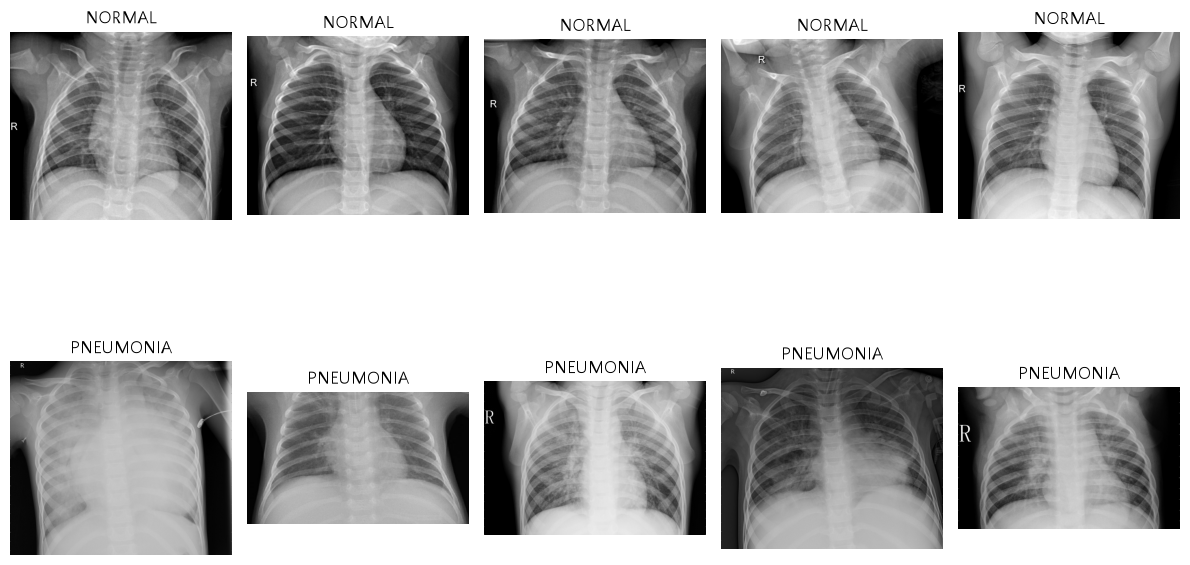

In [29]:
# ============================================================
# Representative Images (실제 이미지 5건 추출 후 육안 비교)
# ============================================================

viewer = ImageViewer()

viewer.show_by_group(
    image_info,
    train_path,
    group_column="Folder",
    n=5,
    random_state=42
)

#### 이미지 최대/최소 사이즈
- 이미지 사이즈가 다양하고 비율도 비정형적

In [ ]:
group_summary = ImageAnalyzer.summarize_by_group(
    image_info,
    group_column="Folder"
)

group_summary

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# 데이터 준비
# ============================================================

# 데이터 건수
count_data = image_info["Folder"].value_counts()

count_ratio = (
    count_data / count_data.sum() * 100
)

# Width / Height 평균
size_mean = (
    image_info
    .groupby("Folder")[["Width", "Height"]]
    .mean()
)

size_ratio = (
    size_mean.div(size_mean.sum(axis=0)) * 100
)


# ============================================================
# 그래프
# ============================================================

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Class Distribution",
        "Mean Image Size"
    ]
)

# ------------------------------------------------------------
# 1. 데이터 건수
# ------------------------------------------------------------

fig.add_trace(
    go.Bar(
        x=count_ratio.index,
        y=count_ratio.values,
        text=[f"{v:.1f}%" for v in count_ratio.values],
        textposition="auto",
        name="Count"
    ),
    row=1,
    col=1
)


# ------------------------------------------------------------
# 2. Width / Height 평균
# ------------------------------------------------------------

for dimension in ["Width", "Height"]:
    fig.add_trace(
        go.Bar(
            x=size_ratio.index,
            y=size_ratio[dimension],
            text=[
                f"{v:.1f}%"
                for v in size_ratio[dimension]
            ],
            textposition="auto",
            name=dimension
        ),
        row=1,
        col=2
    )


# ============================================================
# Layout
# ============================================================

fig.update_yaxes(
    title_text="Percentage (%)",
    range=[0, 100],
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Percentage (%)",
    range=[0, 100],
    row=1,
    col=2
)

fig.update_layout(
    title="Class Distribution and Mean Image Size",
    barmode="group",
    height=450
)

fig.show()

In [32]:
import plotly.express as px

size_data = image_info.melt(
    id_vars="Folder",
    value_vars=["Width", "Height"],
    var_name="Dimension",
    value_name="Pixels"
)

fig = px.box(
    size_data,
    x="Pixels",
    y="Dimension",
    color="Folder",
    orientation="h",
    title="Image Size Distribution by Class"
)

fig.update_layout(
    xaxis_title="Pixels",
    yaxis_title="Dimension"
)

fig.show()

In [33]:
import plotly.express as px

fig = px.scatter(
    image_info,
    x="Width",
    y="Height",
    color="Folder",
    opacity=0.2,
    title="Image Width vs Height by Class",
    hover_data=["File"]
)

fig.update_layout(
    xaxis_title="Width (pixels)",
    yaxis_title="Height (pixels)"
)

fig.show()

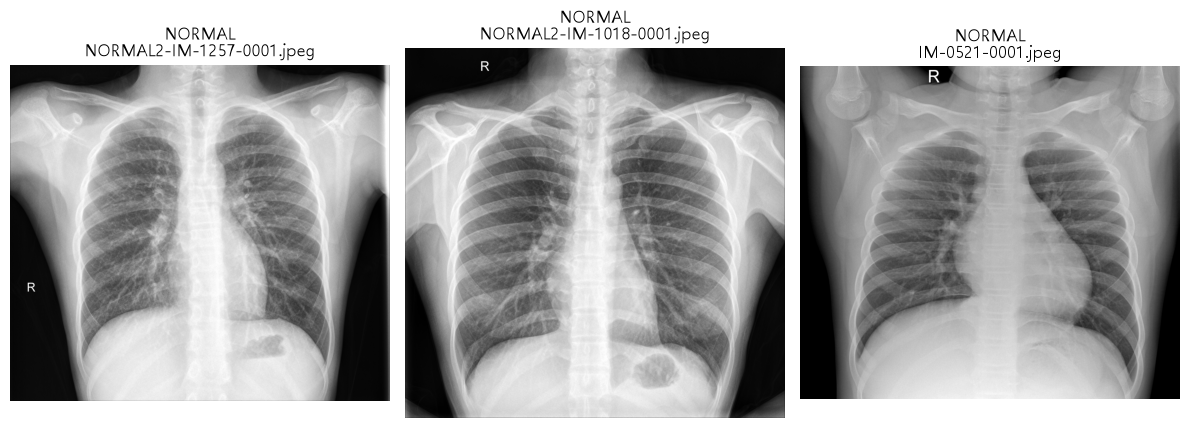

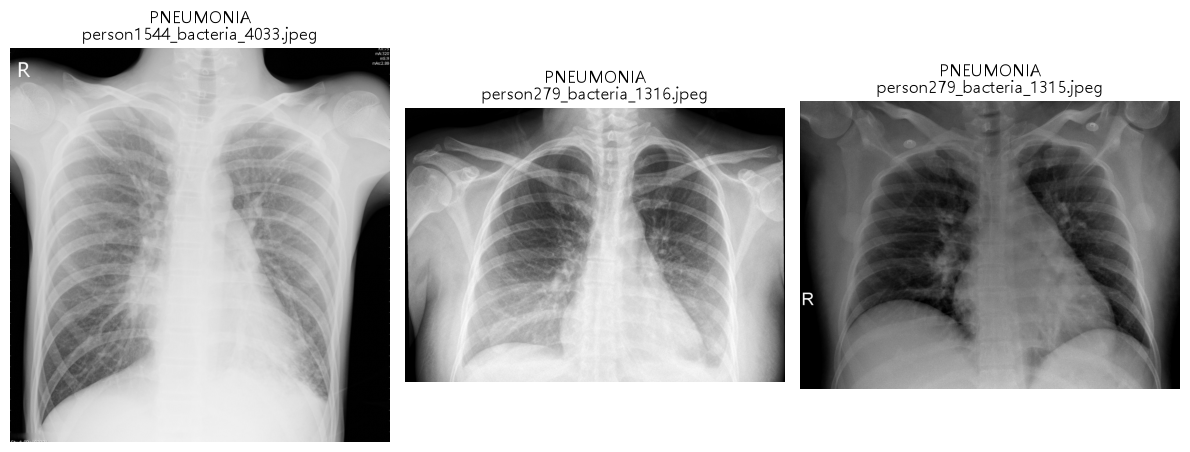

In [34]:
ImageViewer.show_extremes(
    image_info[image_info["Folder"] == "NORMAL"],
    train_path,
    column="Area",
    n=3,
    largest=True
)

ImageViewer.show_extremes(
    image_info[image_info["Folder"] == "PNEUMONIA"],
    train_path,
    column="Area",
    n=3,
    largest=True
)

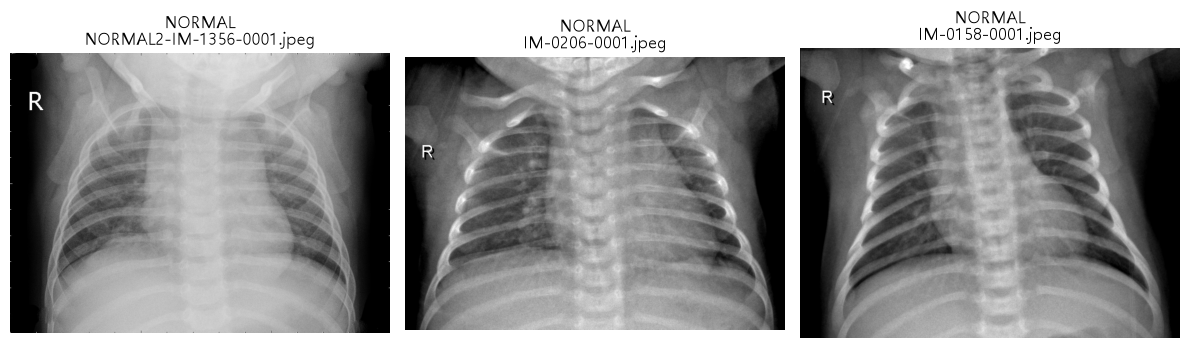

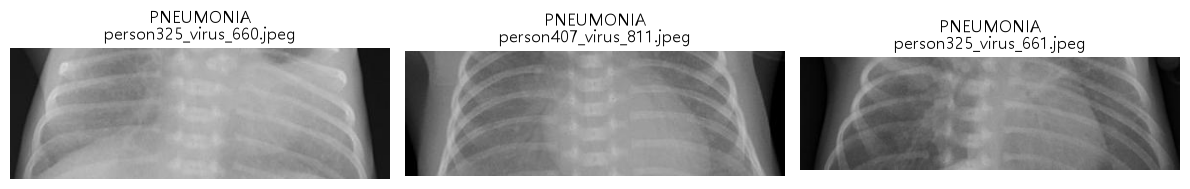

In [35]:
ImageViewer.show_extremes(
    image_info[image_info["Folder"] == "NORMAL"],
    train_path,
    column="Area",
    n=3,
    largest=False
)

ImageViewer.show_extremes(
    image_info[image_info["Folder"] == "PNEUMONIA"],
    train_path,
    column="Area",
    n=3,
    largest=False
)

## 3. 전처리
NORMAL 1,341 / PNEUMONIA 3,875:  약 3배차  (데이터 불균형)<br>
NORMAL 정방형(1.22), PNEUMONIA는 가로가 긴 형태(1.51) 많음<br> 
PEEUMONIA 저해상도 이미지는 폐사진만 있는 경우 확인. 의료장비가 찍힌 이미지도 있음 ( BaseLine 처리후 전처리 추가 필요 )
- 해상도변경 :Resizing(원본비율유지)  -> Padding 으로 사이즈처리  (512 * 512 : 자원 고려. gabage data 방지) 
- 변경된 이미지는 .png로 저장 -> Google Colab Drive에 저장후 진행예정

#### 분석용 이미지 생성

In [ ]:
from pathlib import Path
from ailib.image import ImageManager


SOURCE_DIR = Path(SRC_FOLDER)
OUTPUT_DIR = SOURCE_DIR.parent / "chest_xray_processed"
IMAGE_SIZE = (512, 512)

# train / val / test → 클래스 폴더까지 순회
for split in ["train", "val", "test"]:

    for class_dir in (SOURCE_DIR / split).iterdir():

        if not class_dir.is_dir():
            continue

        output_dir = OUTPUT_DIR / split / class_dir.name
        output_dir.mkdir(parents=True, exist_ok=True)

        for image_path in class_dir.iterdir():

            if image_path.suffix.lower() not in {
                ".jpg", ".jpeg", ".png"
            }:
                continue

            # 이미지 처리
            image = ImageManager.load_image(image_path)
            image = ImageManager.convert(image, "L")
            image = ImageManager.resize_with_padding(
                image,
                IMAGE_SIZE
            )

            # PNG로 저장
            output_path = (
                output_dir / f"{image_path.stem}.png"
            )

            ImageManager.save_image(
                image,
                output_path,
                format="PNG"
            )

print("Preprocessing completed.") 


Preprocessing completed.


In [ ]:

 
PROC_FOLDER = "data/chest-xray-pneumonia/chest_xray_processed"
 

train_proc_path  = Path(PROC_FOLDER) / "train"
val_proc_path   = Path(PROC_FOLDER) / "val"
test_proc_path = Path(PROC_FOLDER) / "test"


normal_files = list((train_proc_path / "NORMAL").glob("*"))
pneumonia_files = list((train_proc_path / "PNEUMONIA").glob("*"))

print("NORMAL:", len(normal_files))
print("PNEUMONIA:", len(pneumonia_files))

NORMAL: 1341
PNEUMONIA: 3875


#### Mean/std 

In [ ]:
# Mean/std는 실데이터로 처리해야해서 임의로 path 지정함
## colab은 content 압축파일에서 처리
train_proc_path2  = "data/chest-xray-pneumonia/chest_xray_processed/train"
 
processed_image_info = ImageInspector.inspect_dataset(
    train_proc_path2
)
processed_image_info.head(5)

In [ ]:
from pathlib import Path

CSV_PATH = Path("processed_image_info.csv")

processed_image_info.to_csv(
    CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved: {CSV_PATH}")

Saved: processed_image_info.csv


In [ ]:
import pandas as pd
from pathlib import Path

 
#PC
CSV_PATH =  "processed_image_info.csv"
processed_image_info = pd.read_csv(
    CSV_PATH
)

print(processed_image_info.shape)
processed_image_info.head()

(5216, 16)


,Folder,File,Format,Width,Height,Shape,Channels,Mode,DType,File Size (KB),Missing,Min,Max,Mean,Std,Error
0,NORMAL,IM-0115-0001.png,PNG,512,512,"(512, 512)",1,L,uint8,118.64,0,0.0,255.0,114.555859,71.308384,NaN
1,NORMAL,IM-0117-0001.png,PNG,512,512,"(512, 512)",1,L,uint8,109.97,0,0.0,255.0,81.580200,66.686144,NaN
2,NORMAL,IM-0119-0001.png,PNG,512,512,"(512, 512)",1,L,uint8,101.07,0,0.0,255.0,96.720387,78.689893,NaN
3,NORMAL,IM-0122-0001.png,PNG,512,512,"(512, 512)",1,L,uint8,104.06,0,0.0,255.0,105.191998,79.088869,NaN
4,NORMAL,IM-0125-0001.png,PNG,512,512,"(512, 512)",1,L,uint8,94.27,0,0.0,255.0,74.686970,72.977164,NaN


In [16]:
# 전체 Train 픽셀 평균
global_mean = processed_image_info["Mean"].mean()

# 전체 Train 픽셀 분산
global_var = (
    (processed_image_info["Std"] ** 2)
    + (processed_image_info["Mean"] - global_mean) ** 2
).mean()

# 전체 Train 픽셀 표준편차
global_std = global_var ** 0.5

# ToTensor() 이후 0~1 범위로 변환
mean = global_mean / 255
std = global_std / 255

print(f"Mean: {mean:.6f}")
print(f"Std : {std:.6f}")

Mean: 0.345086
Std : 0.297072


## 4. Conclusion

이번 단계에서는 Chest X-Ray 데이터셋의 구조와 이미지 특성을 확인하고, 이후 모델 학습에 사용할 전처리 기준을 정의하였다.

주요 확인 내용은 다음과 같다.
 
* NORMAL / PNEUMONIA 클래스 분포 확인
* Train/Val/Test 및 클래스 분포 확인
* 이미지 해상도와 가로·세로 비율의 차이 확인
* 대표 이미지 및 해상도 극단값을 통한 이미지 특성 확인
* 클래스별 이미지 특성을 바탕으로 전처리 방향 결정
* 원본 비율을 유지한 Resiziong과 Padding을 적용한 512 × 512 이미지 생성
* 전처리된 Train 데이터의 실제 픽셀 분포를 기반으로 Mean / Std 계산 -> Pre-trained model 기준의 Mean /Std로 변경해서 진행하였음

분석 결과를 바탕으로 이후 단계에서는 전처리된 데이터를 사용하여 Dataset / DataLoader를 구성하고,  Transfer Learning 실험을 진행한다.
대상 모델은 ResNet50, DenseNet121

### Experiments Notebook 
[02. Experiments Notebook](./02_chest_xray_experiments.ipynb.ipynb)<br>
→ Transfer Learning 실험 설정 및 학습 실행<br><br>

### Analysis Notebook 
[03-1.Experiments MetaData](./03-1_chest_xray_experiment_meta.ipynb.ipynb.ipynb))<br>
→ 실험 설정과 Run 결과를 Metadata로 정리)<br><br>

[03-2.ResNet50 Experiment Analysis](./03-2_chest_xray_experiment_analysis.ipynb))<br>
→ ResNet50 실험 결과 비교 및 Validation 평가)<br>
<!-- [03-2.DenseNet121 Experiment Analysis ](./03-2_chest_xray_experiment_analysis.ipynb))<br> -->
